In [ ]:

def compute_AM_Grossman(Ef1, Ef2):
    """
    Ef1, Ef2: shape (N, 3) 형태의 전기장 벡터 배열
    """
    eps = 1e-15 # 0으로 나누기 방지용 미세값
    
    # sol1_amp, sol2_amp
    n1 = np.linalg.norm(Ef1, axis=1)
    n2 = np.linalg.norm(Ef2, axis=1)
    n1 = np.where(n1 == 0, eps, n1)
    n2 = np.where(n2 == 0, eps, n2)
    
    # E1_amp (max), E2_amp (min) 및 해당 벡터 할당
    cond = n1 > n2
    E_max = np.where(cond[:, None], Ef1, Ef2)  # E1_x, E1_y, E1_z
    E_min = np.where(cond[:, None], Ef2, Ef1)  # E2_x, E2_y, E2_z
    E1_amp = np.where(cond, n1, n2)
    E2_amp = np.where(cond, n2, n1)
    
    # cosB 및 ang 계산
    dot_prod = np.sum(E_max * E_min, axis=1)
    cosB = dot_prod / (E1_amp * E2_amp)
    cosB = np.clip(cosB, -1.0, 1.0) # acos 에러 방지
    ang = np.arccos(cosB)
    
    # ang < pi/2 에 따른 분기 (파일의 if 조건문들)
    acute_cond = ang < (np.pi / 2)
    
    # txt 파일의 E2_x 분기와 동일한 효과: 예각이면 그대로, 둔각이면 방향 반전
    E_min_adj = np.where(acute_cond[:, None], E_min, -E_min)
    cosA = np.where(acute_cond, cosB, -cosB) 
    
    # Ex_m, Ey_m, Ez_m 계산
    E_m = E_max - E_min_adj
    norm_E_m = np.linalg.norm(E_m, axis=1)
    norm_E_m = np.where(norm_E_m == 0, eps, norm_E_m)
    
    # cosBB 및 sinBB 계산
    dot_max_min_adj = np.sum(E_max * E_min_adj, axis=1)
    num_cosBB = -(E2_amp**2) + dot_max_min_adj
    den_cosBB = E2_amp * norm_E_m
    cosBB = num_cosBB / den_cosBB
    cosBB = np.clip(cosBB, -1.0, 1.0)
    sinBB = np.sin(np.arccos(cosBB))
    
    # 최종 AM_vector 산출
    am_cond = E2_amp < (E1_amp * cosA)
    AM_vector = np.where(am_cond, 2 * E2_amp, 2 * E2_amp * sinBB)
    
    return AM_vector

In [3]:
def load_leadfield_data(filepath):
    """
    COMSOL CSV 파일을 불러와 (전극 수, 포인트 수, 3차원 성분)의 Numpy 텐서로 변환.
    동적으로 전극 개수를 자동 파악합니다.
    """
    print(f"Loading {filepath}...")
    # 상단 주석(% 시작)을 스킵하고 데이터 로드 (보통 8~9줄)
    df = pd.read_csv(filepath, comment='%')
    
    # 전극 개수 자동 계산: (전체 열 개수 - 3(좌표계)) / 3(x,y,z 성분)
    num_electrodes = (df.shape[1] - 3) // 3
    num_points = df.shape[0]
    
    # 복소수 기호 'i'를 파이썬의 'j'로 변환 후 수치화
    field_cols = df.iloc[:, 3:]
    
    # 데이터 정리 (빈칸 제거, i를 j로 변환, 결측치 0 처리)
    parsed_fields = np.zeros(field_cols.shape, dtype=np.complex128)
    for i in range(field_cols.shape[1]):
        col_str = field_cols.iloc[:, i].fillna('0').astype(str).str.replace(' ', '').str.replace('i', 'j', regex=False)
        parsed_fields[:, i] = np.array([complex(x) for x in col_str])
        
    # 준정적 전기장의 방향(음/양)을 보존하기 위해 실수부 추출 (중요!)
    parsed_fields = np.real(parsed_fields)
    
    # (전극 수, 포인트 수, 3) 형태로 재배열
    E_tensor = np.zeros((num_electrodes, num_points, 3))
    for e in range(num_electrodes):
        E_tensor[e, :, 0] = parsed_fields[:, e*3]     # Ex
        E_tensor[e, :, 1] = parsed_fields[:, e*3 + 1] # Ey
        E_tensor[e, :, 2] = parsed_fields[:, e*3 + 2] # Ez
        
    print(f"-> 완료! 형태: {E_tensor.shape} (전극 수 {num_electrodes}개, 메쉬 포인트 {num_points}개)")
    return E_tensor

# --- 사용자 파일 경로 설정 (경로를 맞게 수정해주세요) ---
# 예: 'nerve_leadfield_f1.csv', 'offtarget_leadfield_f1.csv' 등
E_nerve_f1 = load_leadfield_data('nerve_leadfield_f1.csv')
E_nerve_f2 = load_leadfield_data('nerve_leadfield_f2.csv')
E_off_f1 = load_leadfield_data('offtarget_f1.csv')
E_off_f2 = load_leadfield_data('offtarget_f2.csv')

Loading nerve_leadfield_f1.csv...
-> 완료! 형태: (21, 13291, 3) (전극 수 21개, 메쉬 포인트 13291개)
Loading nerve_leadfield_f2.csv...
-> 완료! 형태: (15, 13291, 3) (전극 수 15개, 메쉬 포인트 13291개)
Loading offtarget_f1.csv...
-> 완료! 형태: (21, 112217, 3) (전극 수 21개, 메쉬 포인트 112217개)
Loading offtarget_f2.csv...
-> 완료! 형태: (15, 112217, 3) (전극 수 15개, 메쉬 포인트 112217개)


In [4]:
# f1 전극 개수(21), f2 전극 개수(15) 추출
num_f1_elec = E_nerve_f1.shape[0] 
num_f2_elec = E_nerve_f2.shape[0]

# 순서와 상관없는 조합(Combinations) 생성
f1_pairs = list(itertools.combinations(range(num_f1_elec), 2))
f2_pairs = list(itertools.combinations(range(num_f2_elec), 2))

print(f"총 탐색할 조합 수: {len(f1_pairs) * len(f2_pairs):,} 개")
results = []

start_time = time.time()

# 최적화 연산 루프
for a, b in f1_pairs:
    # f1 벡터 합성: (전극 A - 전극 B)
    Ef1_nerve = E_nerve_f1[a] - E_nerve_f1[b]
    Ef1_off = E_off_f1[a] - E_off_f1[b]
    
    for c, d in f2_pairs:
        # f2 벡터 합성: (전극 C - 전극 D)
        Ef2_nerve = E_nerve_f2[c] - E_nerve_f2[d]
        Ef2_off = E_off_f2[c] - E_off_f2[d]
        
        # 앞서 만든 우회 수식 함수로 AM_vector 산출
        AM_nerve = compute_AM_Grossman(Ef1_nerve, Ef2_nerve)
        AM_off = compute_AM_Grossman(Ef1_off, Ef2_off)
        
        # 해당 조합에서의 최대 진폭(Max) 추출
        nerve_max = np.max(AM_nerve)
        off_max = np.max(AM_off)
        
        # 결과 기록 (전극 번호는 1부터 시작하도록 +1 보정)
        results.append({
            'f1_A': a+1, 'f1_B': b+1,
            'f2_C': c+22, 'f2_D': d+22,
            'nerve_max': nerve_max,
            'off_max': off_max
        })

df_results = pd.DataFrame(results)
print(f"연산 완료! 소요 시간: {time.time() - start_time:.2f} 초")

총 탐색할 조합 수: 22,050 개
연산 완료! 소요 시간: 392.28 초


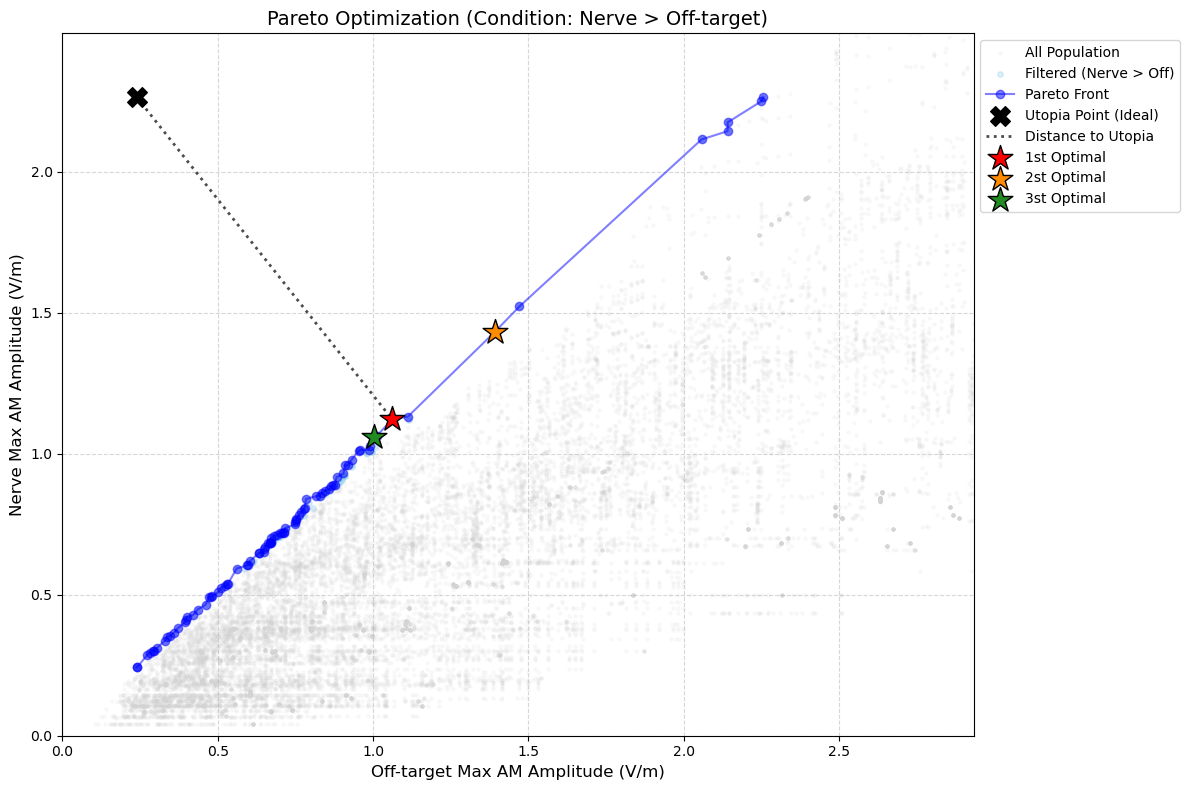


🏆 [설하신경 자극 최적 전극 배치 TOP 3 결과] 🏆

🥇 [1위 조합]
- f1 주파수 전극 쌍: 3번, 15번
- f2 주파수 전극 쌍: 24번, 36번
  > Target Nerve 강도 : 1.1221 V/m
  > Off-target 강도   : 1.0616 V/m
  > 단순 Selectivity  : 1.06

🥈 [2위 조합]
- f1 주파수 전극 쌍: 9번, 10번
- f2 주파수 전극 쌍: 23번, 28번
  > Target Nerve 강도 : 1.4332 V/m
  > Off-target 강도   : 1.3928 V/m
  > 단순 Selectivity  : 1.03

🥉 [3위 조합]
- f1 주파수 전극 쌍: 3번, 15번
- f2 주파수 전극 쌍: 24번, 31번
  > Target Nerve 강도 : 1.0590 V/m
  > Off-target 강도   : 1.0021 V/m
  > 단순 Selectivity  : 1.06



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. 유효 데이터 필터링 (Nerve 강도가 Off-target보다 큰 경우) ---
df_filtered = df_results[df_results['nerve_max'] > df_results['off_max']].copy()

if df_filtered.empty:
    print("⚠️ 조건(Nerve > Off-target)을 만족하는 조합이 없습니다. 주입 전류나 좌표를 확인하세요.")
else:
    # 파레토 효율 점 계산 함수
    def get_pareto_front(costs):
        is_efficient = np.ones(costs.shape[0], dtype=bool)
        for i, c in enumerate(costs):
            if is_efficient[i]:
                is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1)
                is_efficient[i] = True  
                is_efficient[is_efficient] = ~np.all(costs[is_efficient] > c, axis=1)
                is_efficient[i] = True
        return is_efficient

    # --- 2. 파레토 최적화 수행 ---
    # Off-target 최소화, Nerve 최대화(- 부호 사용)
    costs_filtered = np.column_stack((df_filtered['off_max'].values, -df_filtered['nerve_max'].values))
    pareto_mask = get_pareto_front(costs_filtered)
    df_pareto = df_filtered[pareto_mask].copy()

    # 유토피아 포인트(이상적인 지점) 정의
    x_ideal = df_pareto['off_max'].min()
    y_ideal = df_pareto['nerve_max'].max()

    # 정규화된 유클리드 거리 계산 (타협점 도출)
    x_norm = (df_pareto['off_max'] - x_ideal) / (df_pareto['off_max'].max() - x_ideal + 1e-9)
    y_norm = (df_pareto['nerve_max'] - y_ideal) / (df_pareto['nerve_max'].min() - y_ideal + 1e-9)
    df_pareto['distance_to_utopia'] = np.sqrt(x_norm**2 + y_norm**2)
    top3_combinations = df_pareto.nsmallest(3, 'distance_to_utopia')

    # --- 3. 시각화 (그래프) ---
    plt.figure(figsize=(12, 8))
    
    # 전체 분포 및 필터링 영역
    plt.scatter(df_results['off_max'], df_results['nerve_max'], color='lightgray', s=5, alpha=0.1, label='All Population')
    plt.scatter(df_filtered['off_max'], df_filtered['nerve_max'], color='skyblue', s=15, alpha=0.3, label='Filtered (Nerve > Off)')

    # 파레토 프론트 라인
    df_pareto_sorted = df_pareto.sort_values('off_max')
    plt.plot(df_pareto_sorted['off_max'], df_pareto_sorted['nerve_max'], color='blue', marker='o', alpha=0.5, label='Pareto Front')

    # 유토피아 포인트 및 최단 거리 점선
    plt.scatter(x_ideal, y_ideal, color='black', marker='X', s=200, label='Utopia Point (Ideal)', zorder=20)
    first_place = top3_combinations.iloc[0]
    plt.plot([x_ideal, first_place['off_max']], [y_ideal, first_place['nerve_max']], 
             color='black', linestyle=':', linewidth=2, alpha=0.7, label='Distance to Utopia')

    # 상위 3개 조합 하이라이트
    colors = ['red', 'darkorange', 'forestgreen']
    for i, (_, row) in enumerate(top3_combinations.iterrows()):
        plt.scatter(row['off_max'], row['nerve_max'], color=colors[i], marker='*', s=350, 
                    edgecolors='black', label=f'{i+1}st Optimal', zorder=25)

    # 시각화 범위 집중 (데이터 밀집 구역 확대)
    plt.xlim(0, df_pareto['off_max'].max() * 1.3)
    plt.ylim(0, df_pareto['nerve_max'].max() * 1.1)

    plt.xlabel('Off-target Max AM Amplitude (V/m)', fontsize=12)
    plt.ylabel('Nerve Max AM Amplitude (V/m)', fontsize=12)
    plt.title('Pareto Optimization (Condition: Nerve > Off-target)', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

    # --- 4. ✨ 텍스트 결과 리포트 출력 ✨ ---
    print("\n" + "="*60)
    print("🏆 [설하신경 자극 최적 전극 배치 TOP 3 결과] 🏆")
    print("="*60)

    medals = ['🥇 [1위 조합]', '🥈 [2위 조합]', '🥉 [3위 조합]']
    
    for i, (_, row) in enumerate(top3_combinations.iterrows()):
        print(f"\n{medals[i]}")
        print(f"- f1 주파수 전극 쌍: {int(row['f1_A'])}번, {int(row['f1_B'])}번")
        print(f"- f2 주파수 전극 쌍: {int(row['f2_C'])}번, {int(row['f2_D'])}번")
        print(f"  > Target Nerve 강도 : {row['nerve_max']:.4f} V/m")
        print(f"  > Off-target 강도   : {row['off_max']:.4f} V/m")
        print(f"  > 단순 Selectivity  : {row['nerve_max'] / row['off_max']:.2f}")
    
    print("\n" + "="*60)